In [ ]:
import pandas as pd

acc = pd.read_csv("accident.csv", low_memory=False)
veh = pd.read_csv("vehicle.csv",  low_memory=False)
per = pd.read_csv("person.csv",   low_memory=False)

In [ ]:
# HIGH_COST Logit Model — CRSS 2023 (FINAL, with ALCOHOL from accident.csv)
# - Outcome HIGH_COST (vehicle-level): TOWED OR ROLLOVER OR FIRE_EXP OR DEFORMED==6
# - Speed: median imputation + SP_MISSING (do NOT drop unknown speeds)
# - Driver covariates (person.csv, drivers only): AGE, SEX, UNBUCKLED + BELT_UNKNOWN, DRUGS (+ DRUGS_UNKNOWN)
# - Accident covariate (accident.csv): ALCOHOL (+ ALCOHOL_UNKNOWN)
# - SEATPOS removed (near-constant for drivers)
# - Cluster-robust SE by crash (CASENUM)
#
# IMPORTANT: For 2023 "TOWED" coding, the manual shows that 2022+ has codes 6="Towed" and 7="Towed, Unknown Reason".
# Some CRSS extracts also use 5 for towed in other years/variants; below we include {6,7} for 2023.
# If your file uses different coding, adjust `flag_towed` accordingly after checking value counts.

import warnings
warnings.filterwarnings("ignore", message="cov_type not fully supported with var_weights")

import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf


# helpers
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def topn_other(series, topn):
    vc = series.value_counts(dropna=False)
    top = vc.head(topn).index
    return series.where(series.isin(top), "Other")

def to_num(s):
    return pd.to_numeric(s, errors="coerce")

def debug_find_cols(df, keywords):
    kw = tuple(k.lower() for k in keywords)
    return [c for c in df.columns if any(k in c.lower() for k in kw)]

# 1) FIND REQUIRED COLUMNS

# --- accident.csv ---
hour_col   = pick_col(acc, ["HOUR_IM", "HOUR"])
weath_col  = pick_col(acc, ["WEATHR_IMNAME", "WEATHERNAME", "WEATHER_IMNAME", "WEATHER"]) #WEATHER_IMNAME not in acc???
light_col  = pick_col(acc, ["LGTCON_IMNAME", "LGT_CONDNAME", "LGT_COND_IMNAME", "LGT_COND"]) #LGT_COND_IMNAME not in acc???
region_col = pick_col(acc, ["REGIONNAME", "REGION"])
urban_col  = pick_col(acc, ["URBANICITYNAME", "URBANICITY"])
alcohol_col = pick_col(acc, ["ALCOHOL_IM", "ALCOHOL_IMNAME", "ALCOHOL", "ALCOHOLNAME"]) #ALCOHOL_IM, ALCOHOL_IMNAME not on acc???

vehno_col  = pick_col(veh, ["VEH_NO"])
trav_col   = pick_col(veh, ["TRAV_SP"])
p2_col     = pick_col(veh, ["P_CRASH2NAME", "P_CRASH2"])
vsur_col   = pick_col(veh, ["VSURCONDNAME", "VSURCOND"])
body_col   = pick_col(veh, ["ICFINALBODYNAME", "BODY_TYPNAME", "VPICBODYCLASSNAME", "BODY_TYP"])
modyr_col  = pick_col(veh, ["MOD_YEAR"])
w_col      = pick_col(veh, ["WEIGHT"])
towed_col  = pick_col(veh, ["TOWED"])
roll_col   = pick_col(veh, ["ROLLOVER"])
fire_col   = pick_col(veh, ["FIRE_EXP"])
deform_col = pick_col(veh, ["DEFORMED"])

vehno_p  = pick_col(per, ["VEH_NO"])
pertyp   = pick_col(per, ["PER_TYP"])
age_col  = pick_col(per, ["AGE_IM", "AGE"])
sex_col  = pick_col(per, ["SEX_IMNAME", "SEXNAME", "SEX_IM", "SEX"])
rest_col = pick_col(per, ["RESTUSE_IMNAME", "REST_USE_IMNAME", "REST_USENAME", "REST_USE"]) #RESTUSE_IMNAME, REST_USE_IMNAME not in per???
drugs_col = pick_col(per, ["DRUGS_IM", "DRUGS_IMNAME", "DRUGS", "DRUGSNAME"]) #DRUGS_IM, DRUGS_IMNAME not in per???

# 2) BUILD vehicle-level base table + HIGH_COST outcome
v = veh[[
    "CASENUM", vehno_col, trav_col, p2_col, vsur_col,
    body_col, modyr_col, w_col,
    towed_col, roll_col, fire_col, deform_col
]].copy()

v[vehno_col] = to_num(v[vehno_col])

v["W"] = to_num(v[w_col])

v["TOWED_c"] = to_num(v[towed_col])
v["ROLL_c"]  = to_num(v[roll_col])
v["FIRE_c"]  = to_num(v[fire_col])
v["DEF_c"]   = to_num(v[deform_col])

flag_towed  = v["TOWED_c"].isin([6, 7])
flag_roll   = v["ROLL_c"].eq(3)
flag_fire   = v["FIRE_c"].eq(1)
flag_deform = v["DEF_c"].eq(6)

v["HIGH_COST"] = (flag_towed | flag_roll | flag_fire | flag_deform).astype(int)

print(f"HIGH_COST rate (unweighted): {v['HIGH_COST'].mean():.3f}")
print(f"HIGH_COST=1: {v['HIGH_COST'].sum():,}  |  HIGH_COST=0: {(v['HIGH_COST']==0).sum():,}")

# 3) SPEED: impute missing, add SP_MISSING
v["TRAV_SP_RAW"] = to_num(v[trav_col])
v["TRAV_SP_REAL"] = np.where((v["TRAV_SP_RAW"] >= 1) & (v["TRAV_SP_RAW"] <= 151), v["TRAV_SP_RAW"], np.nan)
v["SP_MISSING"] = v["TRAV_SP_REAL"].isna().astype(int)

median_sp = v["TRAV_SP_REAL"].median()
v["TRAV_SP_REAL"] = v["TRAV_SP_REAL"].fillna(median_sp)

print("\nSpeed imputation:")
print(f"  Median speed used for imputation: {median_sp:.1f} mph")
print(f"  Rows with unknown speed (SP_MISSING=1): {v['SP_MISSING'].sum():,} ({v['SP_MISSING'].mean()*100:.1f}%)")

# 4) Vehicle categorical covariates
v["P2"]   = v[p2_col].fillna("Unknown").astype("object")
v["VSUR"] = v[vsur_col].fillna("Unknown").astype("object")
v["BODY"] = v[body_col].fillna("Unknown").astype("object")
v["MOD_YEAR"] = to_num(v[modyr_col])

# 5) Crash-level covariates (accident.csv): NIGHT/WEATHER/LIGHT/REGION/URBAN + ALCOHOL
a = acc[["CASENUM", hour_col, weath_col, light_col, region_col, urban_col, alcohol_col]].copy()

a[hour_col] = to_num(a[hour_col])
a["NIGHT"] = ((a[hour_col] >= 20) | (a[hour_col] <= 5)).astype(int)

# Normalize categorical fields
a = a.rename(columns={
    weath_col:  "WEATHER",
    light_col:  "LIGHT",
    region_col: "REGION_USE",
    urban_col:  "URBAN_USE",
})

# ALCOHOL coding (per your screenshot for 2016+):
# 1 = Alcohol involved; 2 = No alcohol involved; 8 = N/A; 9 = Unknown
# We'll create: ALCOHOL_INV (1/0) and ALCOHOL_UNKNOWN dummy.
alc_num = to_num(a[alcohol_col])
a["ALCOHOL_INV"] = np.where(alc_num == 1, 1,
                     np.where(alc_num == 2, 0, np.nan))
a["ALCOHOL_UNKNOWN"] = a["ALCOHOL_INV"].isna().astype(int)
a["ALCOHOL_INV"] = a["ALCOHOL_INV"].fillna(0).astype(int)

for c in ["WEATHER", "LIGHT", "REGION_USE", "URBAN_USE"]:
    a[c] = a[c].fillna("Unknown").astype("object")

a = a[["CASENUM", "NIGHT", "WEATHER", "LIGHT", "REGION_USE", "URBAN_USE", "ALCOHOL_INV", "ALCOHOL_UNKNOWN"]].drop_duplicates("CASENUM")
v = v.merge(a, on="CASENUM", how="inner")

# 6) Driver covariates (person.csv): AGE/SEX/UNBUCKLED + DRUGS
d = per[["CASENUM", vehno_p, pertyp, age_col, sex_col, rest_col, drugs_col]].copy()
d[vehno_p] = to_num(d[vehno_p])
d = d.dropna(subset=["CASENUM", vehno_p]).copy()
d = d[d[pertyp] == 1].copy()  # drivers only
d = d.rename(columns={vehno_p: "VEH_NO_JOIN"})

d["AGE"] = to_num(d[age_col])
d["SEX"] = d[sex_col].fillna("Unknown").astype("object")
d["REST"] = d[rest_col].fillna("Unknown").astype("object")

# UNBUCKLED: robust text search
r = d["REST"].astype(str).str.lower()
d["UNBUCKLED"] = np.where(
    r.str.contains("not used|none used|unrestrained|no belt", regex=True, na=False), 1,
    np.where(r.str.contains("lap|shoulder|used|restrained", regex=True, na=False), 0, np.nan)
)

# DRUGS coding (your screenshot 2018+ later):
# 0 = No drugs, 1 = Yes drugs, 8 = Not reported, 9 = Unknown, (sometimes "reported as unknown")
drug_num = to_num(d[drugs_col])
d["DRUGS_INV"] = np.where(drug_num == 1, 1,
                   np.where(drug_num == 0, 0, np.nan))
d["DRUGS_UNKNOWN"] = d["DRUGS_INV"].isna().astype(int)
d["DRUGS_INV"] = d["DRUGS_INV"].fillna(0).astype(int)

d = d[["CASENUM", "VEH_NO_JOIN", "AGE", "SEX", "UNBUCKLED", "DRUGS_INV", "DRUGS_UNKNOWN"]].copy()

v = v.rename(columns={vehno_col: "VEH_NO_JOIN"})
v = v.merge(d, on=["CASENUM", "VEH_NO_JOIN"], how="left")

# 7) CLEAN — minimal dropna (keep missing belt via dummy)
required_cols = [
    "HIGH_COST", "W",
    "NIGHT", "WEATHER", "LIGHT", "REGION_USE", "URBAN_USE",
    "ALCOHOL_INV", "ALCOHOL_UNKNOWN",
    "TRAV_SP_REAL", "SP_MISSING",
    "MOD_YEAR", "BODY", "P2", "VSUR",
    "AGE", "SEX",
    "DRUGS_INV", "DRUGS_UNKNOWN",
]
v = v.dropna(subset=required_cols).copy()

# Belt unknown handling
v["UNBUCKLED"] = v["UNBUCKLED"].fillna(-1)
v["BELT_UNKNOWN"] = (v["UNBUCKLED"] == -1).astype(int)
v["UNBUCKLED"] = v["UNBUCKLED"].replace(-1, 0).astype(int)

# 8) Reduce category cardinality
v["WEATHER"]    = topn_other(v["WEATHER"].astype("object"), 8)
v["LIGHT"]      = topn_other(v["LIGHT"].astype("object"),   6)
v["REGION_USE"] = topn_other(v["REGION_USE"].astype("object"), 5)
v["URBAN_USE"]  = topn_other(v["URBAN_USE"].astype("object"),  4)
v["P2"]         = topn_other(v["P2"].astype("object"),      12)
v["VSUR"]       = topn_other(v["VSUR"].astype("object"),     7)
v["BODY"]       = topn_other(v["BODY"].astype("object"),    12)
v["SEX"]        = topn_other(v["SEX"].astype("object"),      4)

# 9) Final diagnostics
print(f"\n{'='*55}")
print(f"Final sample: N = {len(v):,} vehicle-level observations")
print(f"HIGH_COST rate (unweighted): {v['HIGH_COST'].mean():.3f}")
w_rate = float((v["HIGH_COST"] * v["W"]).sum() / v["W"].sum())
print(f"HIGH_COST rate (weighted):   {w_rate:.3f}")
print(f"SP_MISSING rate:             {v['SP_MISSING'].mean():.3f}")
print(f"BELT_UNKNOWN rate:           {v['BELT_UNKNOWN'].mean():.3f}")
print(f"ALCOHOL_UNKNOWN rate:        {v['ALCOHOL_UNKNOWN'].mean():.3f}")
print(f"DRUGS_UNKNOWN rate:          {v['DRUGS_UNKNOWN'].mean():.3f}")
print(f"{'='*55}\n")

# 10) Logit model (cluster by CASENUM)
formula = (
    "HIGH_COST ~ "
    "TRAV_SP_REAL + SP_MISSING + NIGHT + "
    "MOD_YEAR + C(BODY) + "
    "UNBUCKLED + BELT_UNKNOWN + AGE + C(SEX) + "
    "ALCOHOL_INV + ALCOHOL_UNKNOWN + "
    "DRUGS_INV + DRUGS_UNKNOWN + "
    "C(WEATHER) + C(LIGHT) + C(REGION_USE) + C(URBAN_USE) + "
    "C(P2) + C(VSUR)"
)

print("Using formula:\n", formula)
print("\nFitting logit with var_weights + cluster-robust SE (CASENUM)...\n")

model = smf.glm(
    formula=formula,
    data=v,
    family=sm.families.Binomial(),
    var_weights=v["W"]
).fit(cov_type="cluster", cov_kwds={"groups": v["CASENUM"]})

print(model.summary())

# 11) McFadden pseudo R² + odds ratios
pseudo_r2 = 1 - model.llf / model.llnull
print(f"\nMcFadden Pseudo R²: {pseudo_r2:.4f}")
print(f"N vehicles in model: {len(v):,}")
print(f"HIGH_COST rate (weighted): {w_rate:.4f}")

or_table = pd.DataFrame({
    "coef": model.params,
    "OR": np.exp(model.params),
    "OR_lo": np.exp(model.conf_int()[0]),
    "OR_hi": np.exp(model.conf_int()[1]),
    "p_value": model.pvalues,
}).round(4)
or_table["significant"] = or_table["p_value"] < 0.05

print("\n--- Significant Odds Ratios ---")
print(or_table[or_table["significant"]].sort_values("OR", ascending=False).to_string())

HIGH_COST rate (unweighted): 0.406
HIGH_COST=1: 35,498  |  HIGH_COST=0: 51,963

Speed imputation:
  Median speed used for imputation: 30.0 mph
  Rows with unknown speed (SP_MISSING=1): 58,278 (66.6%)

Final sample: N = 87,262 vehicle-level observations
HIGH_COST rate (unweighted): 0.406
HIGH_COST rate (weighted):   0.342
SP_MISSING rate:             0.666
BELT_UNKNOWN rate:           0.116
ALCOHOL_UNKNOWN rate:        0.379
DRUGS_UNKNOWN rate:          0.532

Using formula:
 HIGH_COST ~ TRAV_SP_REAL + SP_MISSING + NIGHT + MOD_YEAR + C(BODY) + UNBUCKLED + BELT_UNKNOWN + AGE + C(SEX) + ALCOHOL_INV + ALCOHOL_UNKNOWN + DRUGS_INV + DRUGS_UNKNOWN + C(WEATHER) + C(LIGHT) + C(REGION_USE) + C(URBAN_USE) + C(P2) + C(VSUR)

Fitting logit with var_weights + cluster-robust SE (CASENUM)...

                 Generalized Linear Model Regression Results                  
Dep. Variable:              HIGH_COST   No. Observations:                87262
Model:                            GLM   Df Residuals: 

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


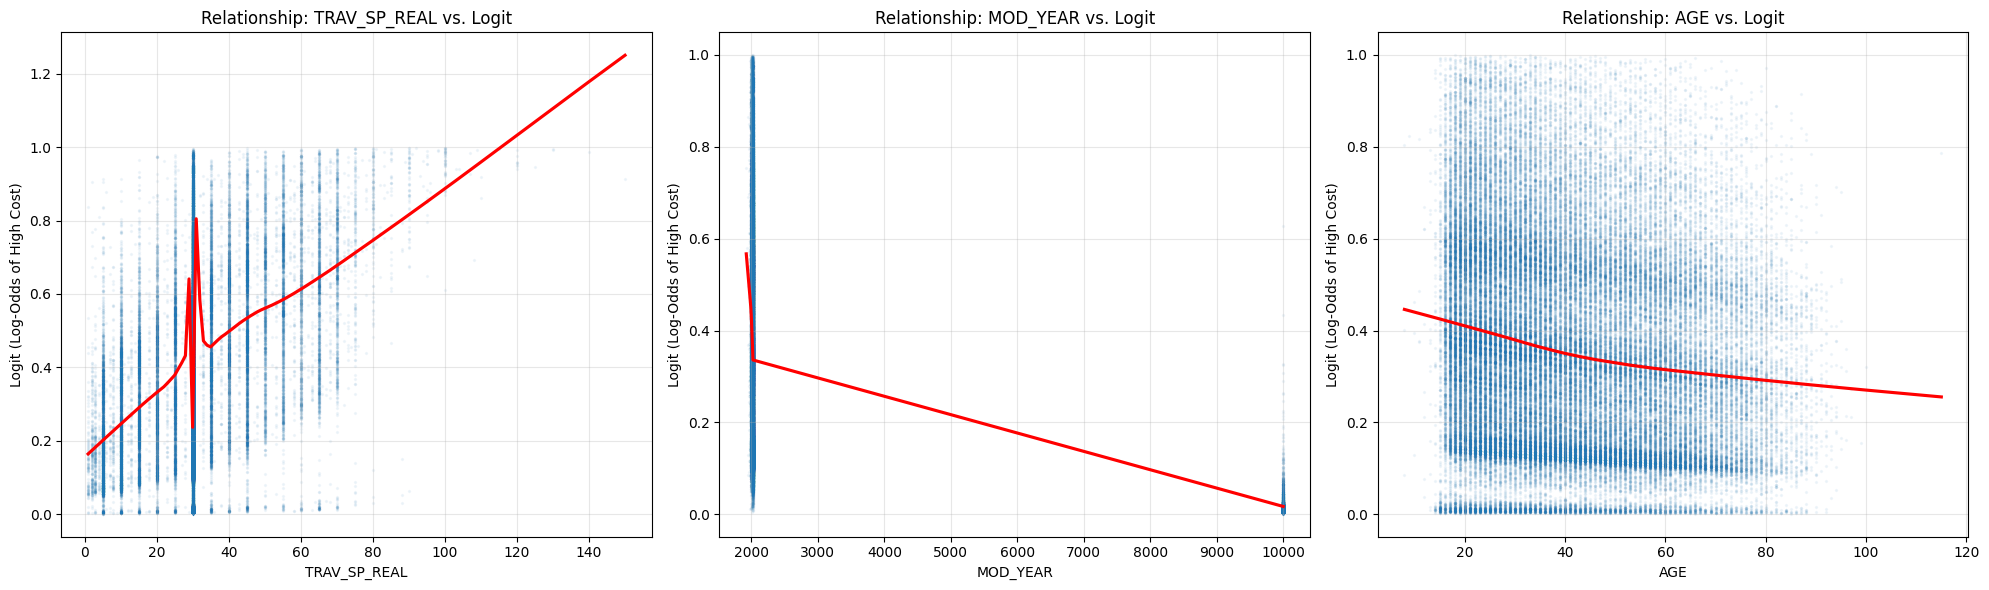

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Calculate the Logit values (Linear Predictor)
# In statsmodels GLM, .fittedvalues returns the linear predictor (log-odds)
v['logit_values'] = model.fittedvalues

# 2. List the predictors to visualize
# We focus on continuous variables for scatter plots
continuous_predictors = ["TRAV_SP_REAL", "MOD_YEAR", "AGE"]

# 3. Create the plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, var in enumerate(continuous_predictors):
    # Scatter plot with a regression line to show the trend
    sns.regplot(
        x=v[var], 
        y=v['logit_values'], 
        data=v, 
        ax=axes[i],
        scatter_kws={'alpha': 0.05, 's': 2}, # Low alpha due to large sample size (N=83k)
        line_kws={'color': 'red'},
        lowess=True # Adds a locally weighted line to reveal non-linear patterns
    )
    
    axes[i].set_title(f'Relationship: {var} vs. Logit')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Logit (Log-Odds of High Cost)')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('predictors_vs_logit.png')

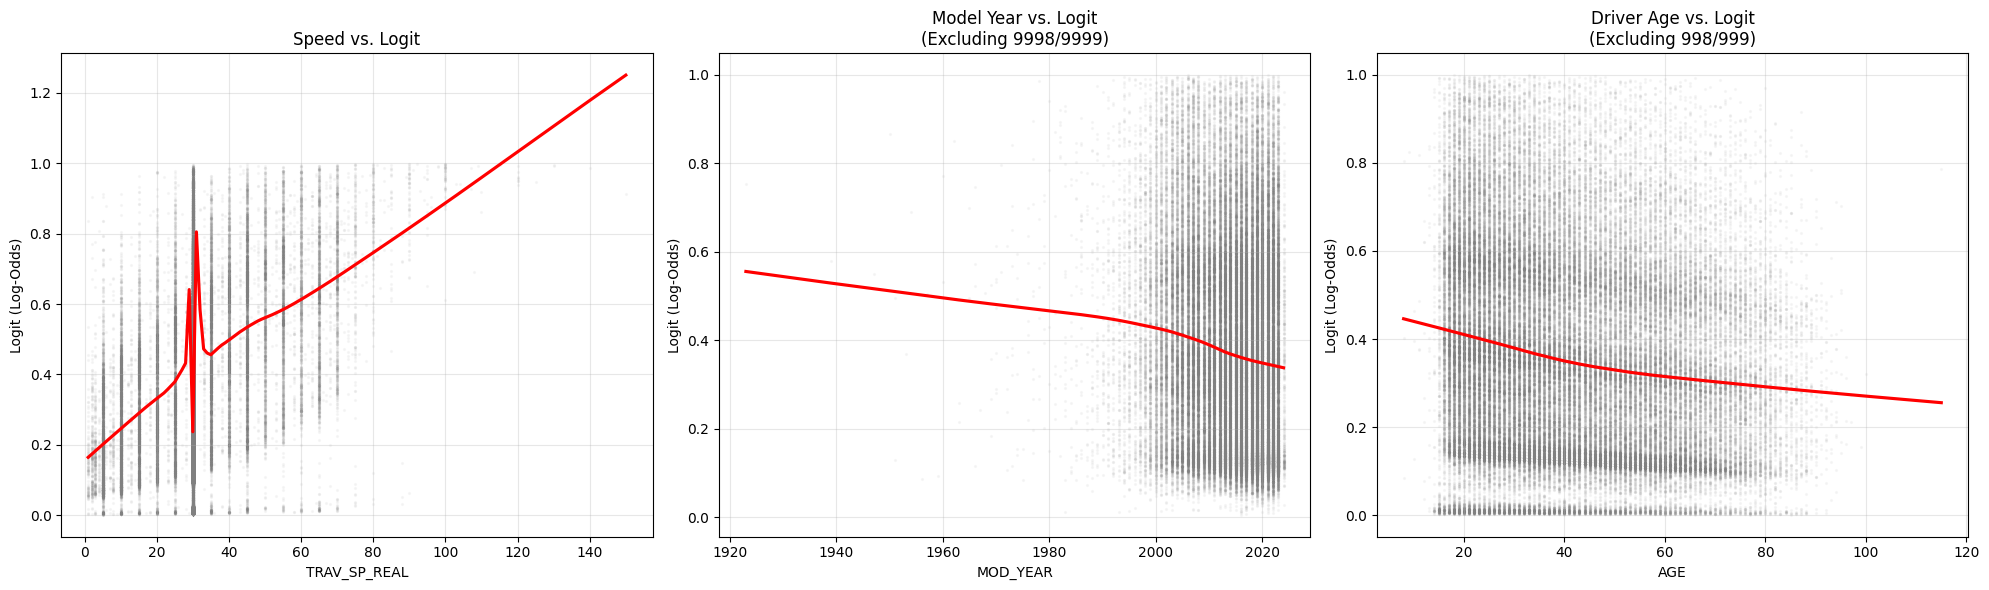

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Calculate Logit values from the fitted model
v['logit_values'] = model.fittedvalues

# 2. Define the plotting function with rule-based filtering
def plot_logit_with_rules(df, var, ax, title):
    # Apply rules from screenshots to temporary plotting dataframe
    if var == 'AGE':
        # Rule: 0-120 are actual ages; 998/999 are placeholder codes
        plot_df = df[df[var] <= 120].copy()
    elif var == 'MOD_YEAR':
        # Rule: Up to 2024 are actual years; 9998/9999 are placeholder codes
        plot_df = df[df[var] <= 2024].copy()
    else:
        plot_df = df.copy()

    # Create the plot
    sns.regplot(
        x=var, 
        y='logit_values', 
        data=plot_df, 
        ax=ax,
        scatter_kws={'alpha': 0.05, 's': 2, 'color': 'gray'},
        line_kws={'color': 'red'},
        lowess=True # Use LOWESS to see if the relationship is truly linear
    )
    
    ax.set_title(title)
    ax.set_xlabel(var)
    ax.set_ylabel('Logit (Log-Odds)')
    ax.grid(True, alpha=0.3)

# 3. Generate the Figure
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot each with their specific rules
plot_logit_with_rules(v, 'TRAV_SP_REAL', axes[0], 'Speed vs. Logit')
plot_logit_with_rules(v, 'MOD_YEAR',      axes[1], 'Model Year vs. Logit\n(Excluding 9998/9999)')
plot_logit_with_rules(v, 'AGE',           axes[2], 'Driver Age vs. Logit\n(Excluding 998/999)')

plt.tight_layout()
plt.show()

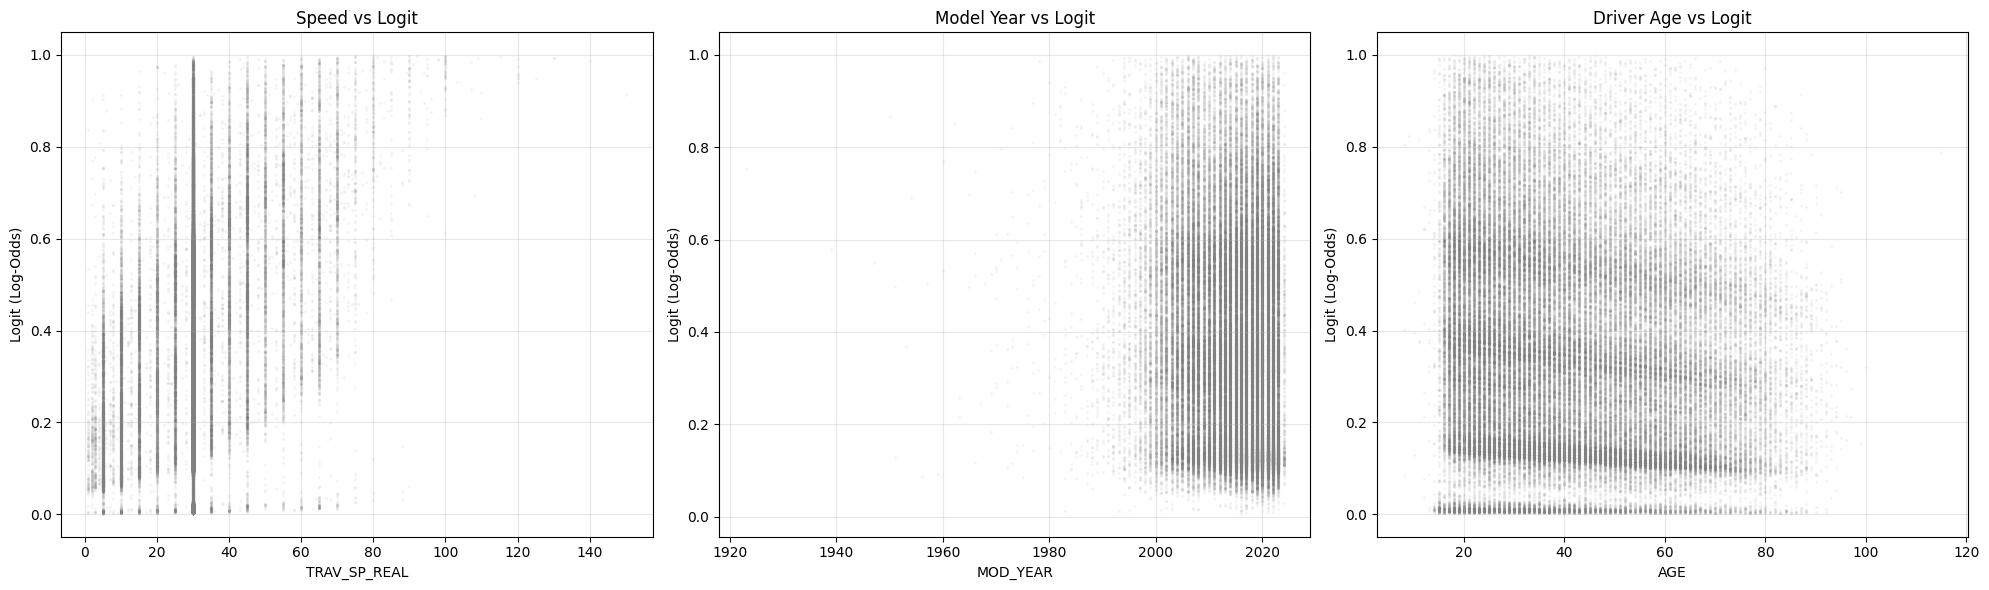

In [58]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

plot_vars = [
    ('TRAV_SP_REAL', 'Speed vs Logit', v['TRAV_SP_REAL'] <= 151),
    ('MOD_YEAR', 'Model Year vs Logit', v['MOD_YEAR'] <= 2024),
    ('AGE', 'Driver Age vs Logit', v['AGE'] <= 120)
]

for i, (var, title, mask) in enumerate(plot_vars):
    plot_df = v[mask].copy()
    
    axes[i].scatter(
        plot_df[var],
        plot_df['logit_values'],
        alpha=0.05,
        s=2,
        color='gray'
    )
    
    axes[i].set_title(title)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Logit (Log-Odds)')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

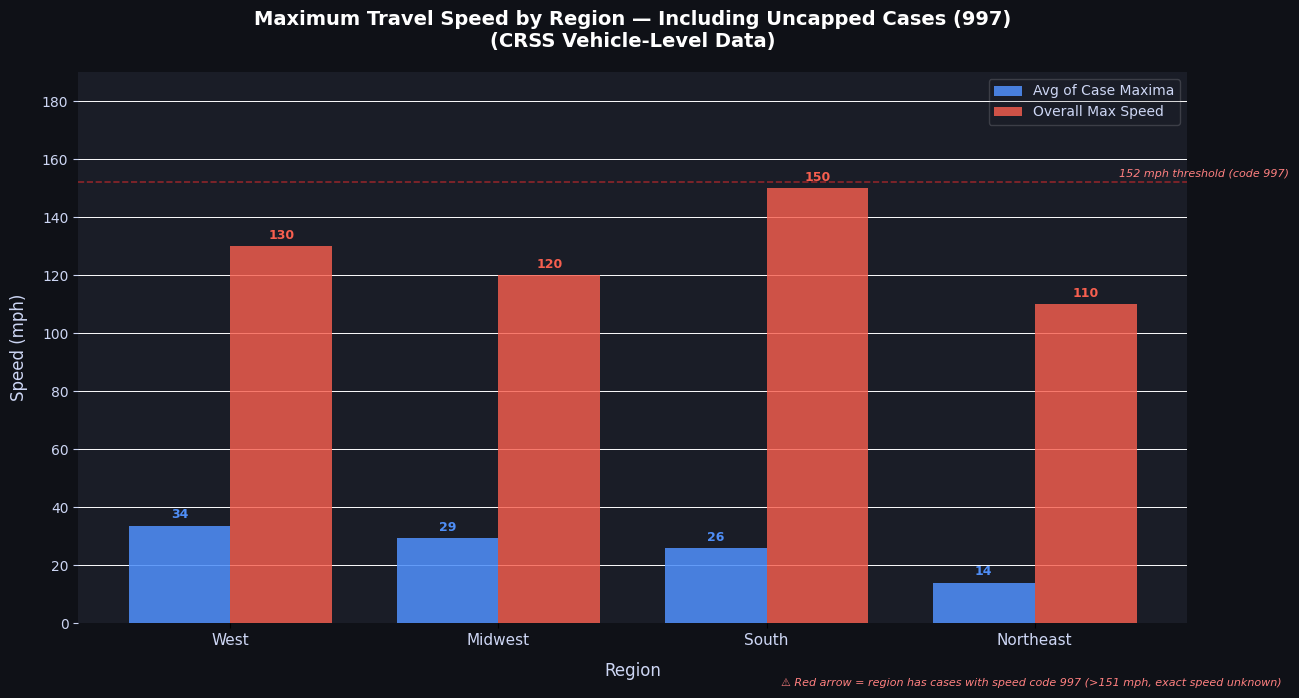

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import FancyArrowPatch

# --- 1. Clean TRAV_SP (two versions) ---
def clean_trav_sp_numeric(val):
    """For average calculation — 997 → 152, unknowns → NaN"""
    if val in (998, 999):
        return np.nan
    elif val == 997:
        return 152
    return val

v_merged['TRAV_SP_clean'] = v_merged['TRAV_SP'].apply(clean_trav_sp_numeric)

# --- 2. Per-case max speed + flag if any vehicle had 997 ---
case_agg = v_merged.groupby(['CASENUM', 'REGIONNAME_y']).agg(
    MAX_SPEED   = ('TRAV_SP_clean', 'max'),
    HAS_997     = ('TRAV_SP',       lambda x: (x == 997).any())
).reset_index()

# --- 3. Per-region stats ---
region_stats = case_agg.groupby('REGIONNAME_y').agg(
    avg_max     = ('MAX_SPEED', 'mean'),
    overall_max = ('MAX_SPEED', 'max'),
    cases_997   = ('HAS_997',   'sum'),   # number of cases with a 997
    total_cases = ('CASENUM',   'count')
).reset_index().sort_values('avg_max', ascending=False)

region_stats['pct_997'] = (
    region_stats['cases_997'] / region_stats['total_cases'] * 100
)
region_stats['Region_short'] = (
    region_stats['REGIONNAME_y'].str.extract(r'^(\w+)')[0]
)

# --- 4. Plot ---
fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

regions   = region_stats['Region_short']
avg_vals  = region_stats['avg_max']
max_vals  = region_stats['overall_max']
has_997   = region_stats['cases_997'] > 0
pct_997   = region_stats['pct_997']
x         = np.arange(len(regions))
bar_w     = 0.38

CLIP_Y    = 160   # y-axis ceiling
ARROW_Y   = 155   # where "overflow" arrow starts

# Cap bars at CLIP_Y for display; real value shown in label
max_display = max_vals.clip(upper=CLIP_Y)

bars_avg = ax.bar(x - bar_w/2, avg_vals,    bar_w,
                  color='#4f8ef7', alpha=0.88, label='Avg of Case Maxima', zorder=3)
bars_max = ax.bar(x + bar_w/2, max_display, bar_w,
                  color='#f75f4f', alpha=0.82, label='Overall Max Speed',  zorder=3)

# --- Value labels ---
for bar, val in zip(bars_avg, avg_vals):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2, val + 1.5,
                f'{val:.0f}', ha='center', va='bottom',
                color='#4f8ef7', fontsize=9, fontweight='bold')

for bar, val, is_997 in zip(bars_max, max_vals, has_997):
    if np.isnan(val):
        continue
    label = '>151 mph ⚠' if is_997 else f'{val:.0f}'
    color = '#ff2d2d' if is_997 else '#f75f4f'
    y_pos = CLIP_Y + 2 if is_997 else val + 1.5
    ax.text(bar.get_x() + bar.get_width()/2, y_pos,
            label, ha='center', va='bottom',
            color=color, fontsize=9, fontweight='bold')

# --- Upward arrows on bars that hit the 997 ceiling ---
for bar, is_997, pct in zip(bars_max, has_997, pct_997):
    if is_997:
        bx = bar.get_x() + bar.get_width() / 2
        ax.annotate('', xy=(bx, CLIP_Y + 10), xytext=(bx, CLIP_Y - 12),
                    arrowprops=dict(arrowstyle='->', color='#ff2d2d',
                                   lw=2.5, mutation_scale=18))
        # % of cases with 997
        ax.text(bx, CLIP_Y + 13,
                f'{pct:.1f}% of cases', ha='center', va='bottom',
                color='#ff8080', fontsize=8, style='italic')

# --- Dashed ceiling line ---
ax.axhline(152, color='#ff2d2d', linewidth=1.2, linestyle='--', alpha=0.5, zorder=2)
ax.text(len(regions) - 0.05, 153, '152 mph threshold (code 997)',
        ha='right', va='bottom', color='#ff8080', fontsize=8, style='italic')

# --- Axes & grid ---
ax.set_ylim(0, CLIP_Y + 30)
ax.yaxis.set_major_locator(ticker.MultipleLocator(20))
ax.grid(axis='y', color='#ffffff18', linewidth=0.7, zorder=0)
ax.set_xticks(x)
ax.set_xticklabels(regions, color='#cdd6f4', fontsize=11)
ax.tick_params(axis='y', colors='#cdd6f4', labelsize=10)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlabel('Region', color='#cdd6f4', fontsize=12, labelpad=10)
ax.set_ylabel('Speed (mph)', color='#cdd6f4', fontsize=12, labelpad=10)
ax.set_title('Maximum Travel Speed by Region — Including Uncapped Cases (997)\n'
             '(CRSS Vehicle-Level Data)',
             color='#ffffff', fontsize=14, fontweight='bold', pad=18)

ax.legend(framealpha=0.15, labelcolor='#cdd6f4', fontsize=10,
          facecolor='#1a1d27', edgecolor='#ffffff22')

fig.text(0.99, 0.01,
         '⚠ Red arrow = region has cases with speed code 997 (>151 mph, exact speed unknown)',
         ha='right', va='bottom', color='#ff8080', fontsize=8, style='italic')

plt.tight_layout()
plt.savefig('max_speed_by_region_997.png', dpi=150, bbox_inches='tight')
plt.show()

  Region_short  median       mean  q25   q75  total  count_997
3         West    25.0  26.806748  5.0  45.0  26349          0
0      Midwest    15.0  21.938733  0.0  35.0  18199          0
2        South    15.0  20.643994  0.0  35.0  63940          0
1    Northeast     0.0   9.743779  0.0  10.0   5023          0


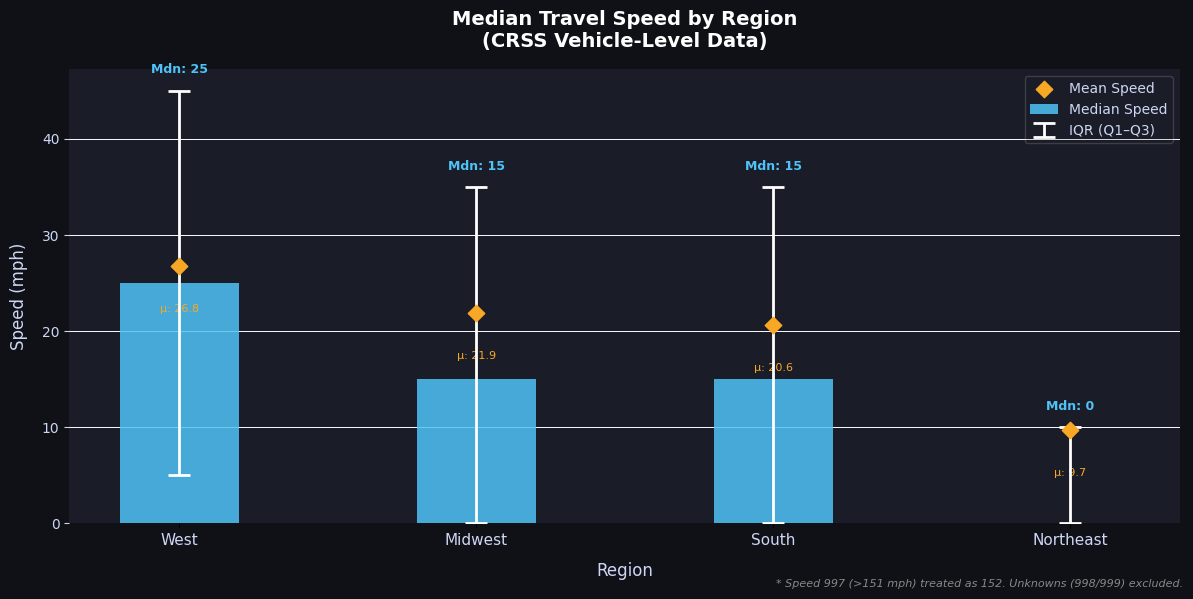

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

v1 = veh.merge(
    per[['CASENUM', 'REGIONNAME']], 
    on='CASENUM', 
    how='left'
)
# --- 1. Clean TRAV_SP ---
def clean_trav_sp(val):
    if val in (998, 999):
        return np.nan
    elif val == 997:
        return 152
    return val

v1['TRAV_SP_clean'] = v1['TRAV_SP'].apply(clean_trav_sp)

# --- 2. Median speed per region ---
region_median = (
    v1.groupby('REGIONNAME_y')['TRAV_SP_clean']
    .agg(
        median      = 'median',
        mean        = 'mean',
        q25         = lambda x: x.quantile(0.25),
        q75         = lambda x: x.quantile(0.75),
        total       = 'count',
        count_997   = lambda x: (v1.loc[x.index, 'TRAV_SP'] == 997).sum()
    )
    .reset_index()
    .sort_values('median', ascending=False)
)

region_median['Region_short'] = (
    region_median['REGIONNAME_y'].str.extract(r'^(\w+)')[0]
)

print(region_median[['Region_short', 'median', 'mean', 'q25', 'q75', 'total', 'count_997']])

# --- 3. Plot ---
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

regions = region_median['Region_short']
medians = region_median['median']
means   = region_median['mean']
q25     = region_median['q25']
q75     = region_median['q75']
x       = np.arange(len(regions))
bar_w   = 0.4

# IQR error bars (Q1 and Q3 as asymmetric whiskers around median)
yerr_low  = (medians - q25).clip(lower=0)
yerr_high = (q75 - medians).clip(lower=0)

bars = ax.bar(x, medians, bar_w,
              color='#4fc3f7', alpha=0.85,
              label='Median Speed', zorder=3)

ax.errorbar(x, medians,
            yerr=[yerr_low, yerr_high],
            fmt='none', color='#ffffff', elinewidth=2,
            capsize=8, capthick=2, zorder=4, label='IQR (Q1–Q3)')

# Mean dots
ax.scatter(x, means, color='#f9a825', s=70, zorder=5,
           label='Mean Speed', marker='D')

# Value labels above bars
for i, (bar, med, mn) in enumerate(zip(bars, medians, means)):
    ax.text(bar.get_x() + bar.get_width()/2, med + yerr_high.iloc[i] + 1.5,
            f'Mdn: {med:.0f}', ha='center', va='bottom',
            color='#4fc3f7', fontsize=9, fontweight='bold')
    ax.text(bar.get_x() + bar.get_width()/2, mn - 4,
            f'μ: {mn:.1f}', ha='center', va='top',
            color='#f9a825', fontsize=8)

# Grid & styling
ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
ax.grid(axis='y', color='#ffffff18', linewidth=0.7, zorder=0)
ax.set_xticks(x)
ax.set_xticklabels(regions, color='#cdd6f4', fontsize=11)
ax.tick_params(axis='y', colors='#cdd6f4', labelsize=10)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlabel('Region', color='#cdd6f4', fontsize=12, labelpad=10)
ax.set_ylabel('Speed (mph)', color='#cdd6f4', fontsize=12, labelpad=10)
ax.set_title('Median Travel Speed by Region\n(CRSS Vehicle-Level Data)',
             color='#ffffff', fontsize=14, fontweight='bold', pad=16)

ax.legend(framealpha=0.15, labelcolor='#cdd6f4', fontsize=10,
          facecolor='#1a1d27', edgecolor='#ffffff22')

fig.text(0.99, 0.01,
         '* Speed 997 (>151 mph) treated as 152. Unknowns (998/999) excluded.',
         ha='right', va='bottom', color='#888', fontsize=8, style='italic')

plt.tight_layout()
plt.savefig('median_speed_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np

# 1. Merge as before
v_merged = veh.merge(
    per[["CASENUM", "REGIONNAME"]],
    on="CASENUM",
    how="left"
)

# 2. Clean the TRAV_SP column 
# We replace codes 997, 998, and 999 with NaN so they don't skew the math
v_merged["TRAV_SP"] = v_merged["TRAV_SP"].mask(v_merged["TRAV_SP"] >= 998, np.nan)

# 3. Calculate median and sort
# Note: Ensure you use "REGIONNAME_y" only if that is the correct column name after merge
median_speed_by_region = (
    v_merged.groupby("REGIONNAME_y")["TRAV_SP"]
    .median()
    .sort_values(ascending=False)
)

print(median_speed_by_region)

REGIONNAME_y
West (MT, ID, WA, OR, CA, NV, NM, AZ, UT, CO, WY, AK, HI)                     25.0
Midwest (OH, IN, IL, MI, WI, MN, ND, SD, NE, IA, MO, KS)                      15.0
South (MD, DE, DC, WV, VA, KY, TN, NC, SC, GA, FL, AL, MS, LA, AR, OK, TX)    15.0
Northeast (PA, NJ, NY, NH, VT, RI, MA, ME, CT)                                 0.0
Name: TRAV_SP, dtype: float64


In [7]:
acc["CASENUM"].isna().sum()

np.int64(0)

In [9]:
v["W"].isna().sum()

np.int64(0)

In [28]:
veh.head()

,CASENUM,VEH_NO,PSU,PSU_VAR,PSUSTRAT,REGION,REGIONNAME,URBANICITY,URBANICITYNAME,STRATUM,...,P_CRASH3,P_CRASH3NAME,PCRASH4,PCRASH4NAME,PCRASH5,PCRASH5NAME,ACC_TYPE,ACC_TYPENAME,ACC_CONFIG,ACC_CONFIGNAME
0,202304632910,1,39,39,7,2,"Midwest (OH, IN, IL, MI, WI, MN, ND, SD, NE, I...",1,Urban Area,10,...,99,Unknown/Not Reported,1,Tracking,4,Departed roadway,99,M99-Unknown,999,Unknown Crash Type
1,202304632916,2,77,77,9,2,"Midwest (OH, IN, IL, MI, WI, MN, ND, SD, NE, I...",2,Rural Area,10,...,99,Unknown/Not Reported,1,Tracking,4,Departed roadway,11,C11-Single Driver-Forward Impact-Parked Veh.,103,Single Driver-Struck Object While Moving Forward
2,202304635310,1,48,48,12,3,"South (MD, DE, DC, WV, VA, KY, TN, NC, SC, GA,...",1,Urban Area,10,...,99,Unknown/Not Reported,1,Tracking,1,Stayed in original travel lane,87,L87-Intersecting Paths-Straight Paths-Struck o...,502,"Intersecting Paths-Straight Paths, Struck on t..."
3,202304635310,2,48,48,12,3,"South (MD, DE, DC, WV, VA, KY, TN, NC, SC, GA,...",1,Urban Area,10,...,99,Unknown/Not Reported,1,Tracking,1,Stayed in original travel lane,86,L86-Intersecting Paths-Straight Paths-Striking...,501,"Intersecting Paths-Straight Paths, Striking fr..."
4,202304635315,1,48,48,12,3,"South (MD, DE, DC, WV, VA, KY, TN, NC, SC, GA,...",1,Urban Area,3,...,1,No Avoidance Maneuver,1,Tracking,1,Stayed in original travel lane,24,"D24-Same Trafficway, Same Direction-Rear End-S...",202,"Same Trafficway, Same Direction-Rear End, Lead..."


In [6]:
acc.head()

,CASENUM,PSU,PSU_VAR,PSUSTRAT,REGION,REGIONNAME,URBANICITY,URBANICITYNAME,STRATUM,STRATUMNAME,...,MAXSEV_IM,MAXSEV_IMNAME,NUM_INJ,NUM_INJNAME,NO_INJ_IM,NO_INJ_IMNAME,ALCOHOL,ALCOHOLNAME,ALCHL_IM,ALCHL_IMNAME
0,202304632910,39,39,7,2,"Midwest (OH, IN, IL, MI, WI, MN, ND, SD, NE, I...",1,Urban Area,10,Stratum 10 - Other,...,0,No Apparent Injury (O),99,All Persons in Crash are Unknown If Injured,0,No Person Injured/Property Damage Only Crash,9,Reported as Unknown,2,No Alcohol Involved
1,202304632916,77,77,9,2,"Midwest (OH, IN, IL, MI, WI, MN, ND, SD, NE, I...",2,Rural Area,10,Stratum 10 - Other,...,0,No Apparent Injury (O),99,All Persons in Crash are Unknown If Injured,0,No Person Injured/Property Damage Only Crash,9,Reported as Unknown,2,No Alcohol Involved
2,202304635310,48,48,12,3,"South (MD, DE, DC, WV, VA, KY, TN, NC, SC, GA,...",1,Urban Area,10,Stratum 10 - Other,...,0,No Apparent Injury (O),0,No Person Injured/Property Damage Only Crash,0,No Person Injured/Property Damage Only Crash,2,No Alcohol Involved,2,No Alcohol Involved
3,202304635315,48,48,12,3,"South (MD, DE, DC, WV, VA, KY, TN, NC, SC, GA,...",1,Urban Area,3,Stratum 3 - Motorcycle Any Injury,...,1,Possible Injury (C),1,1,1,1,2,No Alcohol Involved,2,No Alcohol Involved
4,202304635387,48,48,12,3,"South (MD, DE, DC, WV, VA, KY, TN, NC, SC, GA,...",1,Urban Area,8,Stratum 8 - NLMY PV Minor Injury,...,1,Possible Injury (C),1,1,1,1,9,Reported as Unknown,2,No Alcohol Involved


In [ ]:
list(acc.columns)

In [ ]:
list(veh.columns)

In [ ]:
list(per.columns)

In [29]:
# 1. Clean the speed data first (convert codes >= 997 to NaN)
v_merged["TRAV_SP_CLEAN"] = v_merged["TRAV_SP"].mask(v_merged["TRAV_SP"] >= 997, np.nan)

# 2. Group by CASENUM and find the maximum speed for each crash
max_speed_per_crash = (
    v_merged.groupby("CASENUM")["TRAV_SP_CLEAN"]
    .max()
    .reset_index()
)

# 3. Rename column for clarity
max_speed_per_crash.columns = ["CASENUM", "MAX_VELOCITY"]

print(max_speed_per_crash.head())

        CASENUM  MAX_VELOCITY
0  202304632910           NaN
1  202304632916           NaN
2  202304635310          25.0
3  202304635315          40.0
4  202304635387           0.0


In [45]:
# --- 1. Clean TRAV_SP ---
def clean_trav_sp(val):
    if val in (998, 999):
        return np.nan        # unknown / not reported
    elif val == 997:
        return 152           # "greater than 151" — use 152 as conservative lower bound
                             # alternatively: np.inf if you want to flag it clearly
    else:
        return val           # 0–151 are valid speeds

v_merged['TRAV_SP_clean'] = v_merged['TRAV_SP'].apply(clean_trav_sp)

# --- 2. Max speed per CASENUM ---
max_speed = (
    v_merged.groupby('CASENUM')['TRAV_SP_clean']
    .max()                   # NaN is ignored by default
    .reset_index()
    .rename(columns={'TRAV_SP_clean': 'MAX_SPEED'})
)

print(max_speed)

            CASENUM  MAX_SPEED
0      202304632910        NaN
1      202304632916        NaN
2      202304635310       25.0
3      202304635315       40.0
4      202304635387        0.0
...             ...        ...
50098  202305759012        NaN
50099  202305765489       25.0
50100  202305765520       40.0
50101  202305772712       15.0
50102  202305779265       40.0

[50103 rows x 2 columns]


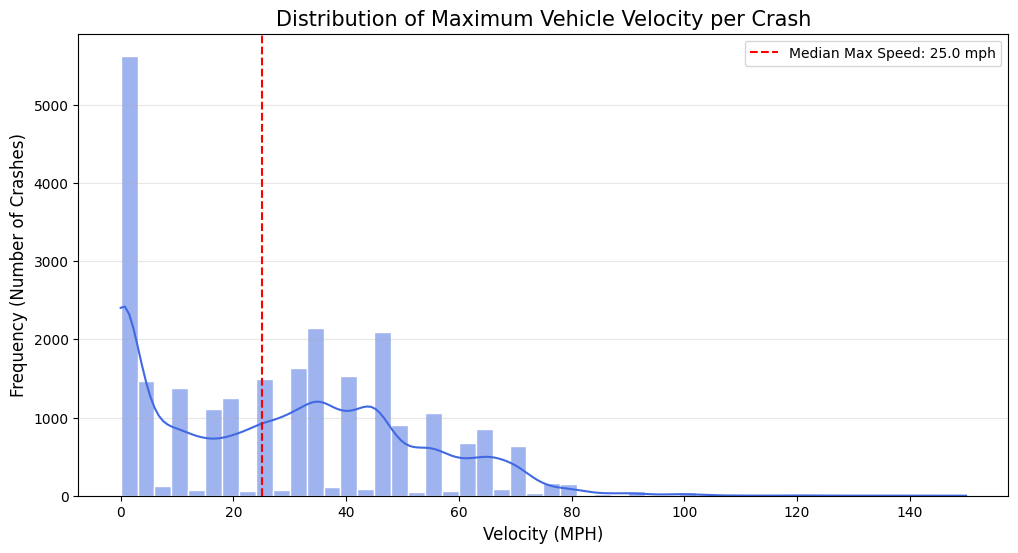

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Clean the speed data
# We treat 997, 998, and 999 as missing data (NaN) 
# so they don't appear as '999 mph' in our plot.
v_merged['TRAV_SP_CLEAN'] = v_merged['TRAV_SP'].mask(v_merged['TRAV_SP'] >= 997, np.nan)

# 2. Get the highest velocity recorded for each crash (CASENUM)
# This ignores the NaNs we just created.
max_speeds = v_merged.groupby('CASENUM')['TRAV_SP_CLEAN'].max().dropna()

# 3. Create the distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(max_speeds, bins=50, kde=True, color='royalblue', edgecolor='white')

# Adding labels and styling
plt.title('Distribution of Maximum Vehicle Velocity per Crash', fontsize=15)
plt.xlabel('Velocity (MPH)', fontsize=12)
plt.ylabel('Frequency (Number of Crashes)', fontsize=12)

# Optional: Add a line for the median to see where the center is
median_val = max_speeds.median()
plt.axvline(median_val, color='red', linestyle='--', label=f'Median Max Speed: {median_val:.1f} mph')

plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

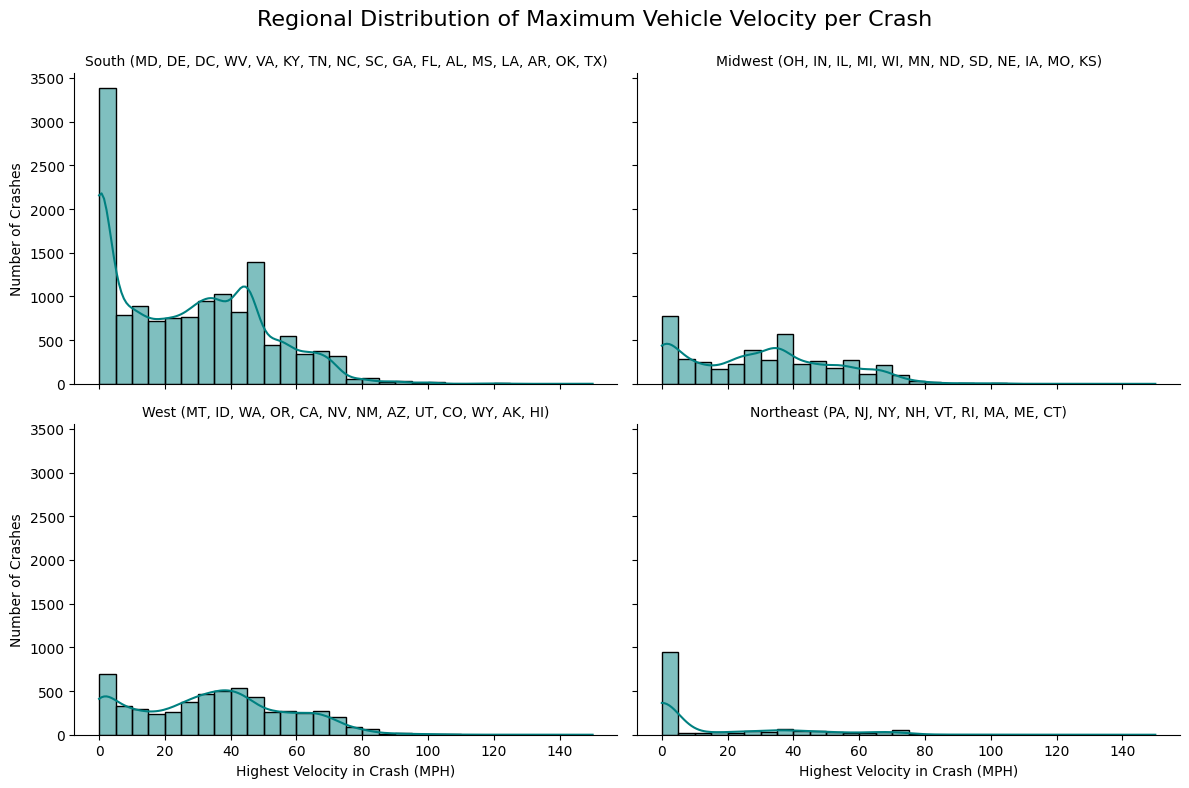

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Merge to ensure we have REGIONNAME in the vehicle data
v_merged = veh.merge(
    per[['CASENUM', 'REGIONNAME']], 
    on='CASENUM', 
    how='left'
)

# 2. Clean the data (treat codes >= 997 as missing)
v_merged['TRAV_SP_CLEAN'] = v_merged['TRAV_SP'].mask(v_merged['TRAV_SP'] >= 997, np.nan)

# 3. Aggregate: Find the highest speed for each specific crash (CASENUM) within its region
# We use both in groupby so we don't lose the region labels
max_speed_df = (
    v_merged.groupby(['CASENUM', 'REGIONNAME_y'])['TRAV_SP_CLEAN'] # Change here
    .max()
    .reset_index()
    .dropna(subset=['TRAV_SP_CLEAN'])
)

# 4. Plotting
# Using displot with col='REGIONNAME' creates a grid of plots (facets)
g = sns.displot(
    data=max_speed_df, 
    x="TRAV_SP_CLEAN", 
    col="REGIONNAME_y",  # Updated to match the DataFrame
    col_wrap=2,
    kind="hist",
    kde=True,
    height=4, 
    aspect=1.5,
    bins=30,
    color="teal"
)

# Formatting the titles and labels
g.set_axis_labels("Highest Velocity in Crash (MPH)", "Number of Crashes")
g.set_titles("{col_name}") # Uses the region name as the title for each subplot
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Regional Distribution of Maximum Vehicle Velocity per Crash', fontsize=16)

plt.show()

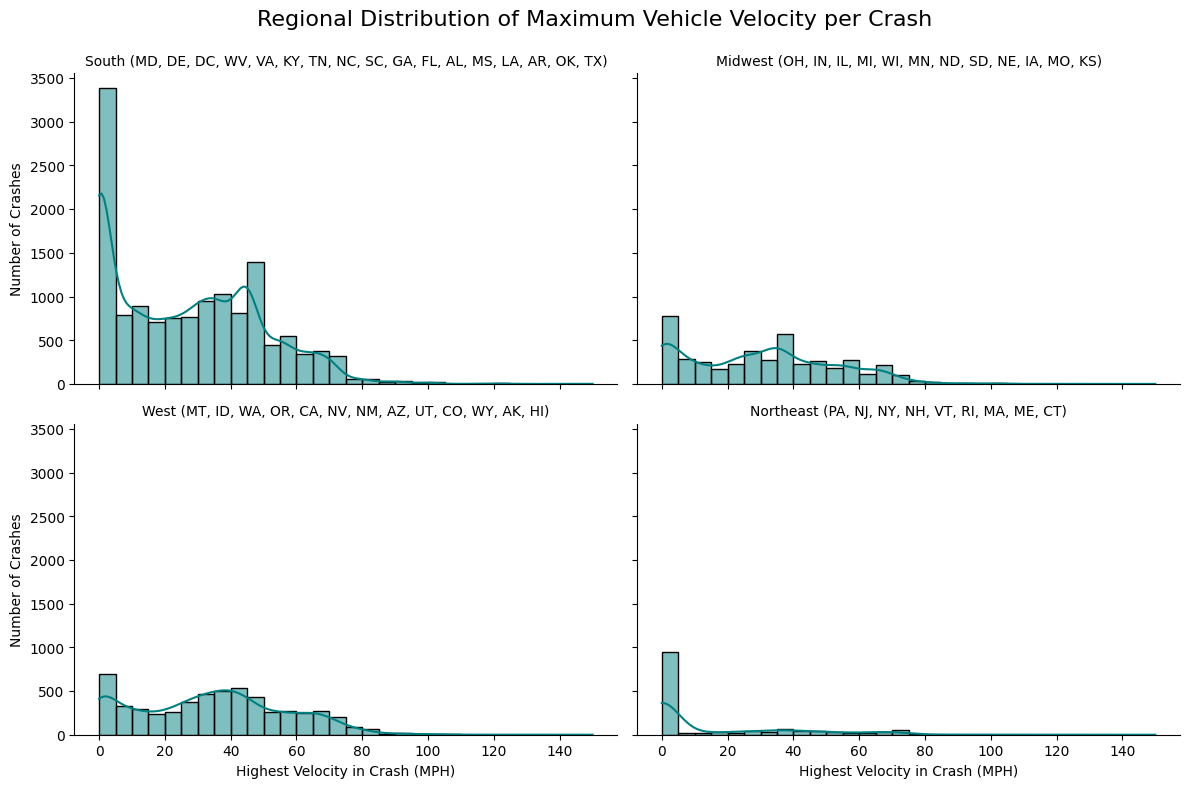

In [46]:
def clean_trav_sp(val):
    if val in (998, 999):
        return np.nan        # unknown / not reported
    elif val == 997:
        return 152           # "greater than 151" — use 152 as conservative lower bound
                             # alternatively: np.inf if you want to flag it clearly
    else:
        return val           # 0–151 are valid speeds

v_merged['TRAV_SP_clean'] = v_merged['TRAV_SP'].apply(clean_trav_sp)

# --- 2. Max speed per CASENUM ---
# max_speed = (
#     v_merged.groupby('CASENUM')['TRAV_SP_clean']
#     .max()                   # NaN is ignored by default
#     .reset_index()
#     .rename(columns={'TRAV_SP_clean': 'MAX_SPEED'})
# )

max_speed_df = (
    v_merged.groupby(['CASENUM', 'REGIONNAME_y'])['TRAV_SP_clean'] # Change here
    .max()
    .reset_index()
    .dropna(subset=['TRAV_SP_clean'])
)

# 4. Plotting
# Using displot with col='REGIONNAME' creates a grid of plots (facets)
g = sns.displot(
    data=max_speed_df, 
    x="TRAV_SP_clean", 
    col="REGIONNAME_y",  # Updated to match the DataFrame
    col_wrap=2,
    kind="hist",
    kde=True,
    height=4, 
    aspect=1.5,
    bins=30,
    color="teal"
)

# Formatting the titles and labels
g.set_axis_labels("Highest Velocity in Crash (MPH)", "Number of Crashes")
g.set_titles("{col_name}") # Uses the region name as the title for each subplot
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Regional Distribution of Maximum Vehicle Velocity per Crash', fontsize=16)

plt.show()

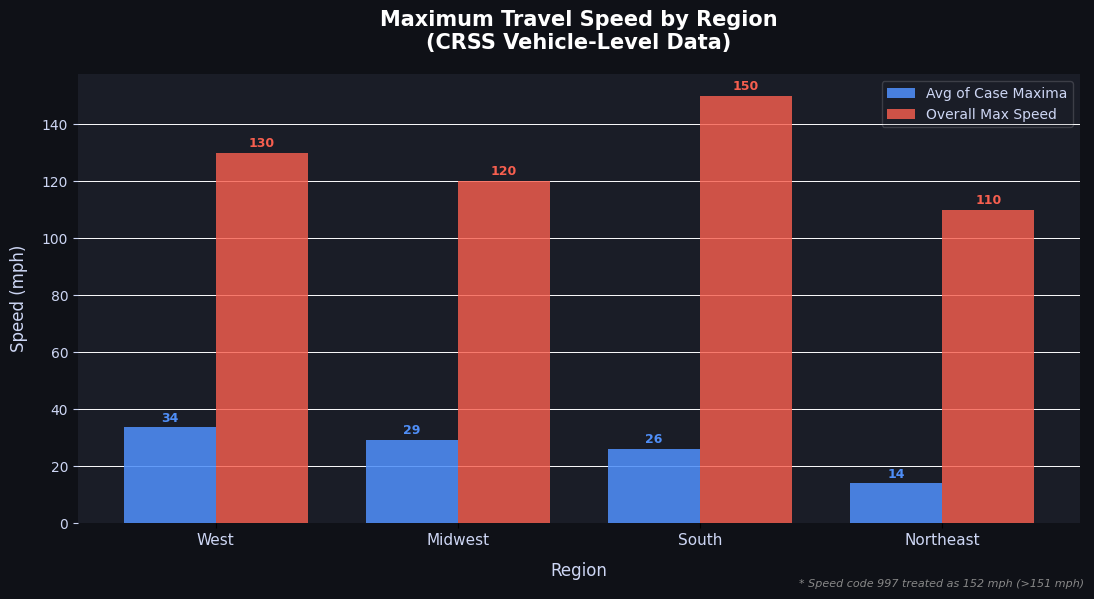

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- 1. Clean TRAV_SP ---
def clean_trav_sp(val):
    if val in (998, 999):
        return np.nan
    elif val == 997:
        return 152  # "greater than 151 mph"
    else:
        return val

v_merged['TRAV_SP_clean'] = v_merged['TRAV_SP'].apply(clean_trav_sp)

# --- 2. Max speed per CASENUM, keeping region info ---
case_max = (
    v_merged.groupby(['CASENUM', 'REGIONNAME_y'])['TRAV_SP_clean']
    .max()
    .reset_index()
    .rename(columns={'TRAV_SP_clean': 'MAX_SPEED'})
)

# --- 3. Max speed per region (average of case maximums) ---
region_stats = (
    case_max.groupby('REGIONNAME_y')['MAX_SPEED']
    .agg(['mean', 'median', 'max', 'count'])
    .reset_index()
    .rename(columns={
        'mean':   'Avg of Case Maxima',
        'median': 'Median of Case Maxima',
        'max':    'Overall Max',
        'count':  'N Cases'
    })
    .sort_values('Avg of Case Maxima', ascending=False)
)

# Shorten long region names for the axis
region_stats['Region_short'] = (
    region_stats['REGIONNAME_y'].str.extract(r'^(\w+)')[0]   # first word, e.g. "Midwest"
)

# --- 4. Plot ---
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

regions   = region_stats['Region_short']
avg_vals  = region_stats['Avg of Case Maxima']
max_vals  = region_stats['Overall Max']
x         = np.arange(len(regions))
bar_w     = 0.38

# Bars
bars_avg = ax.bar(x - bar_w/2, avg_vals, bar_w,
                  color='#4f8ef7', alpha=0.88, label='Avg of Case Maxima', zorder=3)
bars_max = ax.bar(x + bar_w/2, max_vals, bar_w,
                  color='#f75f4f', alpha=0.82, label='Overall Max Speed',  zorder=3)

# Value labels on bars
for bar in bars_avg:
    h = bar.get_height()
    if not np.isnan(h):
        ax.text(bar.get_x() + bar.get_width()/2, h + 1,
                f'{h:.0f}', ha='center', va='bottom',
                color='#4f8ef7', fontsize=9, fontweight='bold')

for bar in bars_max:
    h = bar.get_height()
    if not np.isnan(h):
        label = '>151' if h == 152 else f'{h:.0f}'
        ax.text(bar.get_x() + bar.get_width()/2, h + 1,
                label, ha='center', va='bottom',
                color='#f75f4f', fontsize=9, fontweight='bold')

# Grid & axes
ax.yaxis.set_major_locator(ticker.MultipleLocator(20))
ax.grid(axis='y', color='#ffffff18', linewidth=0.7, zorder=0)
ax.set_xticks(x)
ax.set_xticklabels(regions, color='#cdd6f4', fontsize=11)
ax.tick_params(axis='y', colors='#cdd6f4', labelsize=10)
for spine in ax.spines.values():
    spine.set_visible(False)

# Labels & legend
ax.set_xlabel('Region', color='#cdd6f4', fontsize=12, labelpad=10)
ax.set_ylabel('Speed (mph)', color='#cdd6f4', fontsize=12, labelpad=10)
ax.set_title('Maximum Travel Speed by Region\n(CRSS Vehicle-Level Data)',
             color='#ffffff', fontsize=15, fontweight='bold', pad=18)
ax.legend(framealpha=0.15, labelcolor='#cdd6f4', fontsize=10,
          facecolor='#1a1d27', edgecolor='#ffffff22')

# Note about 997 encoding
fig.text(0.99, 0.01, '* Speed code 997 treated as 152 mph (>151 mph)',
         ha='right', va='bottom', color='#888', fontsize=8, style='italic')

plt.tight_layout()
plt.savefig('max_speed_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

In [42]:
pd.set_option('display.max_columns', None)
v_merged.head()

,CASENUM,VEH_NO,PSU,PSU_VAR,PSUSTRAT,REGION,REGIONNAME_x,URBANICITY,URBANICITYNAME,STRATUM,STRATUMNAME,PJ,WEIGHT,VE_FORMS,MONTH,MONTHNAME,HOUR,HOURNAME,MINUTE,MINUTENAME,HARM_EV,HARM_EVNAME,MAN_COLL,MAN_COLLNAME,NUMOCCS,NUMOCCSNAME,UNITTYPE,UNITTYPENAME,HIT_RUN,HIT_RUNNAME,VIN,VINNAME,MOD_YEAR,MOD_YEARNAME,MDLYR_IM,MDLYR_IMNAME,VPICMAKE,VPICMAKENAME,VPICMODEL,VPICMODELNAME,VPICBODYCLASS,VPICBODYCLASSNAME,MAKE,MAKENAME,MODEL,BODY_TYP,BODY_TYPNAME,ICFINALBODY,ICFINALBODYNAME,GVWR_FROM,GVWR_FROMNAME,GVWR_TO,GVWR_TONAME,TOW_VEH,TOW_VEHNAME,TRLR1VIN,TRLR1VINNAME,TRLR2VIN,TRLR2VINNAME,TRLR3VIN,TRLR3VINNAME,TRLR1GVWR,TRLR1GVWRNAME,TRLR2GVWR,TRLR2GVWRNAME,TRLR3GVWR,TRLR3GVWRNAME,J_KNIFE,J_KNIFENAME,MCARR_ID,MCARR_IDNAME,MCARR_I1,MCARR_I1NAME,MCARR_I2,MCARR_I2NAME,V_Config,V_ConfigNAME,CARGO_BT,CARGO_BTNAME,HAZ_INV,HAZ_INVNAME,HAZ_PLAC,HAZ_PLACNAME,HAZ_ID,HAZ_IDNAME,HAZ_CNO,HAZ_CNONAME,HAZ_REL,HAZ_RELNAME,BUS_USE,BUS_USENAME,SPEC_USE,SPEC_USENAME,EMER_USE,EMER_USENAME,TRAV_SP,TRAV_SPNAME,UNDEROVERRIDE,UNDEROVERRIDENAME,ROLLOVER,ROLLOVERNAME,ROLINLOC,ROLINLOCNAME,IMPACT1,IMPACT1NAME,IMPACT1_IM,IMPACT1_IMNAME,DEFORMED,DEFORMEDNAME,TOWED,TOWEDNAME,M_HARM,M_HARMNAME,VEVENT_IM,VEVENT_IMNAME,FIRE_EXP,FIRE_EXPNAME,DR_PRES,DR_PRESNAME,MAX_VSEV,MAX_VSEVNAME,MXVSEV_IM,MXVSEV_IMNAME,NUM_INJV,NUM_INJVNAME,NUMINJ_IM,NUMINJ_IMNAME,VEH_ALCH,VEH_ALCHNAME,V_ALCH_IM,V_ALCH_IMNAME,MAK_MOD,MAK_MODNAME,DR_ZIP,DR_ZIPNAME,SPEEDREL,SPEEDRELNAME,VTRAFWAY,VTRAFWAYNAME,VNUM_LAN,VNUM_LANNAME,VSPD_LIM,VSPD_LIMNAME,VALIGN,VALIGNNAME,VPROFILE,VPROFILENAME,VSURCOND,VSURCONDNAME,VTRAFCON,VTRAFCONNAME,VTCONT_F,VTCONT_FNAME,P_CRASH1,P_CRASH1NAME,PCRASH1_IM,PCRASH1_IMNAME,P_CRASH2,P_CRASH2NAME,P_CRASH3,P_CRASH3NAME,PCRASH4,PCRASH4NAME,PCRASH5,PCRASH5NAME,ACC_TYPE,ACC_TYPENAME,ACC_CONFIG,ACC_CONFIGNAME,REGIONNAME_y,TRAV_SP_CLEAN
0,202304632910,1,39,39,7,2,"Midwest (OH, IN, IL, MI, WI, MN, ND, SD, NE, I...",1,Urban Area,10,Stratum 10 - Other,4154,210.860191,1,1,January,3,3:00am-3:59am,0,0,53,Mail Box,0,The First Harmful Event was Not a Collision wi...,99,Unknown,1,Motor Vehicle In-Transport (Inside or Outside ...,1,Yes,888888888888,Not Reported,9999,Unknown,2019,2019,99999,Unknown,99999,Unknown,999,Unknown,99,Unknown Make,999,99,Unknown body type,0,Not Applicable,98,Not Reported,98,Not Reported,0,No Trailers,777777777777,No Trailing Units,777777777777,No Trailing Units,777777777777,No Trailing Units,77,No Trailing Units,77,No Trailing Units,77,No Trailing Units,0,Not an Articulated Vehicle,99999999999,Unknown,99,Unknown,999999999,Unknown,99,Unknown,99,Unknown,1,No,0,Not Applicable,0,Not Applicable,0,Not Applicable,0,Not Applicable,99,Reported as Unknown,0,No Special Use Noted,0,Not Applicable,998,Not Reported,7,Not Applicable,0,No Rollover,0,No Rollover,99,Reported as Unknown,12,12 Clock Point,9,Reported as Unknown,5,Not Towed,59,Traffic Sign Support,59,Traffic Sign Support,0,No or Not Reported,1,Yes,9,Unknown/Not Reported,0,No Apparent Injury (O),99,All Persons in Vehicle are unknown if Injured,0,No Person Injured in Vehicle,9,Reported as Unknown,2,No Alcohol Involved,99999,"Unknown Make Unknown (as to automobile, motore...",99998,Not Reported,0,No,1,"Two-Way, Not Divided",2,Two lanes,55,55 MPH,1,Straight,1,Level,1,Dry,0,No Controls,0,No Controls,99,Unknown,1,Going Straight,19,Unknown travel direction,99,Unknown/Not Reported,1,Tracking,4,Departed roadway,99,M99-Unknown,999,Unknown Crash Type,"Midwest (OH, IN, IL, MI, WI, MN, ND, SD, NE, I...",NaN
1,202304632916,2,77,77,9,2,"Midwest (OH, IN, IL, MI, WI, MN, ND, SD, NE, I...",2,Rural Area,10,Stratum 10 - Other,4151,217.379279,1,1,January,7,7:00am-7:59am,51,51,14,Parked Motor Vehicle,0,The First Harmful Event was Not a Collision wi...,99,Unknown,1,Motor Vehicle In-Transport (Inside or Outside ...,1,Yes,888888888888,Not Reported,9999,Unknown,2013,2013,99999,Unknown,99999,Unknown,999,Unknown,99,Unknown Make,999,99,Unknown body type,0,Not Applicable,98,Not Reported,98,Not Reported,0,No Trailers,777777777777,No Trailing Units,77

In [43]:
pd.set_option('display.max_columns', None)
veh.head()

,CASENUM,VEH_NO,PSU,PSU_VAR,PSUSTRAT,REGION,REGIONNAME,URBANICITY,URBANICITYNAME,STRATUM,STRATUMNAME,PJ,WEIGHT,VE_FORMS,MONTH,MONTHNAME,HOUR,HOURNAME,MINUTE,MINUTENAME,HARM_EV,HARM_EVNAME,MAN_COLL,MAN_COLLNAME,NUMOCCS,NUMOCCSNAME,UNITTYPE,UNITTYPENAME,HIT_RUN,HIT_RUNNAME,VIN,VINNAME,MOD_YEAR,MOD_YEARNAME,MDLYR_IM,MDLYR_IMNAME,VPICMAKE,VPICMAKENAME,VPICMODEL,VPICMODELNAME,VPICBODYCLASS,VPICBODYCLASSNAME,MAKE,MAKENAME,MODEL,BODY_TYP,BODY_TYPNAME,ICFINALBODY,ICFINALBODYNAME,GVWR_FROM,GVWR_FROMNAME,GVWR_TO,GVWR_TONAME,TOW_VEH,TOW_VEHNAME,TRLR1VIN,TRLR1VINNAME,TRLR2VIN,TRLR2VINNAME,TRLR3VIN,TRLR3VINNAME,TRLR1GVWR,TRLR1GVWRNAME,TRLR2GVWR,TRLR2GVWRNAME,TRLR3GVWR,TRLR3GVWRNAME,J_KNIFE,J_KNIFENAME,MCARR_ID,MCARR_IDNAME,MCARR_I1,MCARR_I1NAME,MCARR_I2,MCARR_I2NAME,V_Config,V_ConfigNAME,CARGO_BT,CARGO_BTNAME,HAZ_INV,HAZ_INVNAME,HAZ_PLAC,HAZ_PLACNAME,HAZ_ID,HAZ_IDNAME,HAZ_CNO,HAZ_CNONAME,HAZ_REL,HAZ_RELNAME,BUS_USE,BUS_USENAME,SPEC_USE,SPEC_USENAME,EMER_USE,EMER_USENAME,TRAV_SP,TRAV_SPNAME,UNDEROVERRIDE,UNDEROVERRIDENAME,ROLLOVER,ROLLOVERNAME,ROLINLOC,ROLINLOCNAME,IMPACT1,IMPACT1NAME,IMPACT1_IM,IMPACT1_IMNAME,DEFORMED,DEFORMEDNAME,TOWED,TOWEDNAME,M_HARM,M_HARMNAME,VEVENT_IM,VEVENT_IMNAME,FIRE_EXP,FIRE_EXPNAME,DR_PRES,DR_PRESNAME,MAX_VSEV,MAX_VSEVNAME,MXVSEV_IM,MXVSEV_IMNAME,NUM_INJV,NUM_INJVNAME,NUMINJ_IM,NUMINJ_IMNAME,VEH_ALCH,VEH_ALCHNAME,V_ALCH_IM,V_ALCH_IMNAME,MAK_MOD,MAK_MODNAME,DR_ZIP,DR_ZIPNAME,SPEEDREL,SPEEDRELNAME,VTRAFWAY,VTRAFWAYNAME,VNUM_LAN,VNUM_LANNAME,VSPD_LIM,VSPD_LIMNAME,VALIGN,VALIGNNAME,VPROFILE,VPROFILENAME,VSURCOND,VSURCONDNAME,VTRAFCON,VTRAFCONNAME,VTCONT_F,VTCONT_FNAME,P_CRASH1,P_CRASH1NAME,PCRASH1_IM,PCRASH1_IMNAME,P_CRASH2,P_CRASH2NAME,P_CRASH3,P_CRASH3NAME,PCRASH4,PCRASH4NAME,PCRASH5,PCRASH5NAME,ACC_TYPE,ACC_TYPENAME,ACC_CONFIG,ACC_CONFIGNAME
0,202304632910,1,39,39,7,2,"Midwest (OH, IN, IL, MI, WI, MN, ND, SD, NE, I...",1,Urban Area,10,Stratum 10 - Other,4154,210.860191,1,1,January,3,3:00am-3:59am,0,0,53,Mail Box,0,The First Harmful Event was Not a Collision wi...,99,Unknown,1,Motor Vehicle In-Transport (Inside or Outside ...,1,Yes,888888888888,Not Reported,9999,Unknown,2019,2019,99999,Unknown,99999,Unknown,999,Unknown,99,Unknown Make,999,99,Unknown body type,0,Not Applicable,98,Not Reported,98,Not Reported,0,No Trailers,777777777777,No Trailing Units,777777777777,No Trailing Units,777777777777,No Trailing Units,77,No Trailing Units,77,No Trailing Units,77,No Trailing Units,0,Not an Articulated Vehicle,99999999999,Unknown,99,Unknown,999999999,Unknown,99,Unknown,99,Unknown,1,No,0,Not Applicable,0,Not Applicable,0,Not Applicable,0,Not Applicable,99,Reported as Unknown,0,No Special Use Noted,0,Not Applicable,998,Not Reported,7,Not Applicable,0,No Rollover,0,No Rollover,99,Reported as Unknown,12,12 Clock Point,9,Reported as Unknown,5,Not Towed,59,Traffic Sign Support,59,Traffic Sign Support,0,No or Not Reported,1,Yes,9,Unknown/Not Reported,0,No Apparent Injury (O),99,All Persons in Vehicle are unknown if Injured,0,No Person Injured in Vehicle,9,Reported as Unknown,2,No Alcohol Involved,99999,"Unknown Make Unknown (as to automobile, motore...",99998,Not Reported,0,No,1,"Two-Way, Not Divided",2,Two lanes,55,55 MPH,1,Straight,1,Level,1,Dry,0,No Controls,0,No Controls,99,Unknown,1,Going Straight,19,Unknown travel direction,99,Unknown/Not Reported,1,Tracking,4,Departed roadway,99,M99-Unknown,999,Unknown Crash Type
1,202304632916,2,77,77,9,2,"Midwest (OH, IN, IL, MI, WI, MN, ND, SD, NE, I...",2,Rural Area,10,Stratum 10 - Other,4151,217.379279,1,1,January,7,7:00am-7:59am,51,51,14,Parked Motor Vehicle,0,The First Harmful Event was Not a Collision wi...,99,Unknown,1,Motor Vehicle In-Transport (Inside or Outside ...,1,Yes,888888888888,Not Reported,9999,Unknown,2013,2013,99999,Unknown,99999,Unknown,999,Unknown,99,Unknown Make,999,99,Unknown body type,0,Not Applicable,98,Not Reported,98,Not Reported,0,No Trailers,777777777777,No Trailing Units,777777777777,No Trailing Units,777777777777,No Trailing Units,77,No Trailing Units,77,N

In [ ]:
# =============================================================================
# HIGH_COST Logit Model — Full Diagnostics Suite
# Requires: the fitted `model` and DataFrame `v` from the main script
# Run this file AFTER running the main modelling script (or paste both together)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import roc_curve, auc
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ── fonts & palette ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Georgia", "Times New Roman", "DejaVu Serif"],
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.alpha":       0.25,
    "grid.linestyle":   "--",
    "axes.titlesize":   13,
    "axes.labelsize":   11,
    "xtick.labelsize":  9,
    "ytick.labelsize":  9,
    "figure.facecolor": "#F9F7F4",
    "axes.facecolor":   "#F9F7F4",
})

NAVY   = "#1B2A4A"
RUST   = "#C0392B"
TEAL   = "#1A7F72"
GOLD   = "#D4A017"
SLATE  = "#5D6D7E"
CREAM  = "#F9F7F4"

# =============================================================================
# ── SECTION 0: RE-FIT MODEL (copy from main script if needed) ────────────────
# The code below assumes `model` and `v` already exist in the namespace.
# If running standalone, uncomment and paste the full data-prep + model fit
# code from the main script here first.
# =============================================================================

# =============================================================================
# ── HELPERS ──────────────────────────────────────────────────────────────────
# =============================================================================

def weighted_quantile(values, weights, quantiles):
    """Weighted quantile computation."""
    sorter   = np.argsort(values)
    vals     = values[sorter]
    wts      = weights[sorter]
    cumwt    = np.cumsum(wts) / wts.sum()
    return np.interp(quantiles, cumwt, vals)

# =============================================================================
# ── 1. LIKELIHOOD RATIO TEST ─────────────────────────────────────────────────
# =============================================================================
print("=" * 65)
print("1. LIKELIHOOD RATIO TEST")
print("=" * 65)

LR_stat  = -2 * (model.llnull - model.llf)
df_model = model.df_model          # number of non-intercept params
LR_pval  = stats.chi2.sf(LR_stat, df_model)

print(f"  Log-likelihood (full model) : {model.llf:>14.4f}")
print(f"  Log-likelihood (null model) : {model.llnull:>14.4f}")
print(f"  LR statistic (χ²)           : {LR_stat:>14.4f}")
print(f"  Degrees of freedom          : {df_model:>14.0f}")
print(f"  p-value                     : {LR_pval:>14.4e}")
conclusion = "Reject H₀ — model significantly improves over intercept-only." \
             if LR_pval < 0.05 else "Fail to reject H₀."
print(f"  Conclusion: {conclusion}\n")

# =============================================================================
# ── 2. PEARSON χ² (OVERALL GOODNESS-OF-FIT) ──────────────────────────────────
# =============================================================================
print("=" * 65)
print("2. PEARSON χ² (OVERALL GOODNESS-OF-FIT)")
print("=" * 65)

y_obs  = v["HIGH_COST"].values
mu_hat = model.predict()                # fitted probabilities
W      = v["W"].values

# Weighted Pearson residuals: (y - μ) / sqrt(μ(1-μ))
pearson_resid = (y_obs - mu_hat) / np.sqrt(mu_hat * (1 - mu_hat) + 1e-12)
chi2_pearson  = float(np.sum(W * pearson_resid**2))
df_pearson    = len(v) - model.df_model - 1
p_pearson     = stats.chi2.sf(chi2_pearson, df_pearson)

print(f"  Weighted Pearson χ²         : {chi2_pearson:>14.4f}")
print(f"  Degrees of freedom          : {df_pearson:>14.0f}")
print(f"  p-value                     : {p_pearson:>14.4e}")
note = ("NOTE: Very large N makes this test almost always significant — "
        "interpret alongside calibration plot.")
print(f"  {note}\n")

# =============================================================================
# ── 3. HOSMER-LEMESHOW TEST ───────────────────────────────────────────────────
# =============================================================================
print("=" * 65)
print("3. HOSMER-LEMESHOW TEST  (g = 10 groups, weighted)")
print("=" * 65)

g = 10
quantiles_vals = np.linspace(0, 1, g + 1)
# Use weighted quantiles of the fitted probabilities
mu_sorted_edges = weighted_quantile(mu_hat, W, quantiles_vals)
mu_sorted_edges[0]  -= 1e-9
mu_sorted_edges[-1] += 1e-9

hl_stat = 0.0
hl_rows = []
for k in range(g):
    lo, hi = mu_sorted_edges[k], mu_sorted_edges[k + 1]
    mask   = (mu_hat > lo) & (mu_hat <= hi)
    if mask.sum() == 0:
        continue
    Wk   = W[mask].sum()
    Ok   = float((W[mask] * y_obs[mask]).sum())
    Ek   = float((W[mask] * mu_hat[mask]).sum())
    term = (Ok - Ek)**2 / (Ek * (1 - Ek / Wk) + 1e-12)
    hl_stat += term
    hl_rows.append({"Group": k + 1, "N_eff": f"{Wk:,.0f}",
                    "Observed": f"{Ok:,.1f}", "Expected": f"{Ek:,.1f}",
                    "Contribution": f"{term:.3f}"})

df_hl   = g - 2
p_hl    = stats.chi2.sf(hl_stat, df_hl)
hl_df   = pd.DataFrame(hl_rows)
print(hl_df.to_string(index=False))
print(f"\n  HL statistic (χ²)           : {hl_stat:>10.4f}")
print(f"  Degrees of freedom          : {df_hl:>10.0f}")
print(f"  p-value                     : {p_hl:>10.4e}")
calib_ok = "Good calibration (fail to reject H₀)." if p_hl >= 0.05 \
           else "Evidence of miscalibration (reject H₀)."
print(f"  Conclusion: {calib_ok}\n")

# =============================================================================
# ── 4. PSEUDO-R² FAMILY ───────────────────────────────────────────────────────
# =============================================================================
print("=" * 65)
print("4. PSEUDO-R² MEASURES")
print("=" * 65)

llf    = model.llf
ll0    = model.llnull
n      = len(v)
k      = model.df_model + 1          # params including intercept

mcfadden  = 1 - llf / ll0
mcf_adj   = 1 - (llf - k) / ll0     # McFadden adjusted
cox_snell = 1 - np.exp(2 * (ll0 - llf) / n)
nagelkerke = cox_snell / (1 - np.exp(2 * ll0 / n))

print(f"  McFadden R²                 : {mcfadden:>10.4f}")
print(f"  McFadden R² (adjusted)      : {mcf_adj:>10.4f}")
print(f"  Cox-Snell R²                : {cox_snell:>10.4f}")
print(f"  Nagelkerke R²               : {nagelkerke:>10.4f}")
print()
print("  Rule of thumb: McFadden 0.10–0.20 = acceptable, "
      "0.20–0.40 = excellent for logit.\n")

# =============================================================================
# ── 5. INFORMATION CRITERIA ───────────────────────────────────────────────────
# =============================================================================
print("=" * 65)
print("5. INFORMATION CRITERIA")
print("=" * 65)

aic = model.aic
bic = model.bic
print(f"  AIC  : {aic:>14.4f}")
print(f"  BIC  : {bic:>14.4f}")
print(f"  (Lower is better; BIC penalises complexity more heavily)\n")

# =============================================================================
# ── 6. VARIANCE INFLATION FACTORS (VIF) ──────────────────────────────────────
# =============================================================================
print("=" * 65)
print("6. VARIANCE INFLATION FACTORS (VIF)")
print("=" * 65)
print("  (computed on the design matrix used by the model)\n")

# Build the numeric design matrix from the model
X_dm = model.model.exog               # design matrix (already dummified)
X_dm_df = pd.DataFrame(X_dm, columns=model.model.exog_names)

# Drop the intercept for VIF calculation
if "Intercept" in X_dm_df.columns:
    X_dm_df = X_dm_df.drop(columns=["Intercept"])

vif_vals = []
cols     = X_dm_df.columns.tolist()
for i, col in enumerate(cols):
    try:
        vif = variance_inflation_factor(X_dm_df.values, i)
    except Exception:
        vif = np.nan
    vif_vals.append({"Variable": col, "VIF": round(vif, 3)})

vif_df = pd.DataFrame(vif_vals).sort_values("VIF", ascending=False)
print(vif_df.to_string(index=False))
high_vif = vif_df[vif_df["VIF"] > 10]
if len(high_vif):
    print(f"\n  ⚠  Variables with VIF > 10 (potential multicollinearity):")
    print(high_vif.to_string(index=False))
else:
    print("\n  ✓  No variables with VIF > 10.\n")

# =============================================================================
# ── 7. DISCRIMINATION — WEIGHTED ROC-AUC ─────────────────────────────────────
# =============================================================================
print("=" * 65)
print("7. DISCRIMINATION — WEIGHTED ROC-AUC")
print("=" * 65)

# sklearn roc_curve supports sample_weight
fpr, tpr, thresholds = roc_curve(y_obs, mu_hat, sample_weight=W)
roc_auc = auc(fpr, tpr)

print(f"  Weighted ROC-AUC            : {roc_auc:.4f}")
disc = ("Excellent (≥ 0.80)" if roc_auc >= 0.80 else
        "Acceptable (0.70–0.79)" if roc_auc >= 0.70 else
        "Poor (< 0.70)")
print(f"  Interpretation              : {disc}\n")

# Youden index — optimal threshold
youden_idx = np.argmax(tpr - fpr)
opt_thresh  = thresholds[youden_idx]
print(f"  Optimal threshold (Youden)  : {opt_thresh:.4f}")
pred_bin    = (mu_hat >= opt_thresh).astype(int)
sens        = float((W[(pred_bin == 1) & (y_obs == 1)]).sum() /
                    (W[y_obs == 1].sum() + 1e-12))
spec        = float((W[(pred_bin == 0) & (y_obs == 0)]).sum() /
                    (W[y_obs == 0].sum() + 1e-12))
print(f"  Sensitivity at opt. thresh  : {sens:.4f}")
print(f"  Specificity at opt. thresh  : {spec:.4f}\n")

# =============================================================================
# ── 8. PLOTS ──────────────────────────────────────────────────────────────────
# =============================================================================

fig = plt.figure(figsize=(18, 20), facecolor=CREAM)
fig.suptitle(
    "HIGH_COST Logit Model — Diagnostic Dashboard\nCRSS 2023",
    fontsize=18, fontweight="bold", color=NAVY, y=0.98,
    fontfamily="serif"
)

gs = gridspec.GridSpec(3, 2, figure=fig,
                        hspace=0.42, wspace=0.35,
                        left=0.08, right=0.96,
                        top=0.93, bottom=0.06)

# ── 8a. ROC CURVE ────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(fpr, tpr, color=NAVY, lw=2.5,
         label=f"Weighted ROC (AUC = {roc_auc:.3f})")
ax1.plot([0, 1], [0, 1], "--", color=SLATE, lw=1.2, label="Random (AUC = 0.5)")
ax1.scatter(fpr[youden_idx], tpr[youden_idx],
            color=RUST, s=80, zorder=5,
            label=f"Youden optimum (thresh={opt_thresh:.3f})")
ax1.fill_between(fpr, tpr, alpha=0.08, color=NAVY)
ax1.set_xlabel("False Positive Rate (1 − Specificity)")
ax1.set_ylabel("True Positive Rate (Sensitivity)")
ax1.set_title("ROC Curve (Survey-Weighted)", color=NAVY, fontweight="bold")
ax1.legend(fontsize=8, framealpha=0.8)
ax1.set_xlim(-0.01, 1.01); ax1.set_ylim(-0.01, 1.01)

# ── 8b. CALIBRATION PLOT ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])

# group by decile of predicted probability (weighted)
mu_edges  = weighted_quantile(mu_hat, W, np.linspace(0, 1, 11))
mu_edges[0] -= 1e-9; mu_edges[-1] += 1e-9
cal_obs, cal_exp, cal_n = [], [], []
for k in range(10):
    lo, hi = mu_edges[k], mu_edges[k + 1]
    mask   = (mu_hat > lo) & (mu_hat <= hi)
    if mask.sum() == 0:
        continue
    Wk  = W[mask].sum()
    cal_obs.append(float((W[mask] * y_obs[mask]).sum()) / Wk)
    cal_exp.append(float((W[mask] * mu_hat[mask]).sum()) / Wk)
    cal_n.append(mask.sum())

cal_obs = np.array(cal_obs)
cal_exp = np.array(cal_exp)

ax2.plot([0, 1], [0, 1], "--", color=SLATE, lw=1.2, label="Perfect calibration")
ax2.scatter(cal_exp, cal_obs, color=TEAL, s=80, zorder=5,
            edgecolors=NAVY, linewidths=0.8)
# connect points for readability
ax2.plot(cal_exp, cal_obs, color=TEAL, lw=1.5, alpha=0.7)
for i, (xe, yo) in enumerate(zip(cal_exp, cal_obs)):
    ax2.annotate(f"D{i+1}", (xe, yo),
                 textcoords="offset points", xytext=(4, 4), fontsize=7)
ax2.set_xlabel("Mean Predicted Probability")
ax2.set_ylabel("Observed Proportion")
ax2.set_title("Calibration Plot (10 Deciles, Weighted)", color=NAVY, fontweight="bold")
ax2.legend(fontsize=8)

# ── 8c. RESIDUALS VS FITTED ───────────────────────────────────────────────────               # ← same for fitted probabilities
ax3 = fig.add_subplot(gs[1, 0])
dev_resid  = np.asarray(model.resid_deviance)
mu_hat_np  = np.asarray(mu_hat)
pearson_resid_np = np.asarray(pearson_resid)
rng   = np.random.default_rng(42)
idx_s = rng.choice(len(dev_resid), size=min(4000, len(dev_resid)), replace=False)

ax3.scatter(mu_hat_np[idx_s], dev_resid[idx_s],
            alpha=0.25, s=8, color=NAVY, edgecolors="none")

lowess_fit = sm.nonparametric.lowess(dev_resid[idx_s], mu_hat_np[idx_s],
                                     frac=0.3, return_sorted=True)
ax3.plot(lowess_fit[:, 0], lowess_fit[:, 1], color=RUST, lw=2.2, label="LOWESS")
ax3.axhline(0, color=SLATE, lw=1.2, linestyle="--")
ax3.set_xlabel("Fitted Probability")
ax3.set_ylabel("Deviance Residual")
ax3.set_title("Residuals vs Fitted (Deviance, Subsample n=4 000)",
              color=NAVY, fontweight="bold")
ax3.legend(fontsize=8)

# ── 8d. PEARSON RESIDUALS HISTOGRAM ──────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])

pearson_resid_np = pearson_resid.values if hasattr(pearson_resid, "values") \
                   else pearson_resid     # already numpy from earlier calc

pr = pearson_resid_np[idx_s]             # reuse same subsample index
ax4.hist(pr, bins=60, color=TEAL, edgecolor=CREAM, alpha=0.85, density=True)
xr = np.linspace(pr.min(), pr.max(), 300)
ax4.plot(xr, stats.norm.pdf(xr), color=RUST, lw=2.2, label="N(0,1)")
ax4.set_xlabel("Pearson Residual")
ax4.set_ylabel("Density")
ax4.set_title("Pearson Residual Distribution (Subsample)",
              color=NAVY, fontweight="bold")
ax4.legend(fontsize=8)

# ── 8e. CORRELATION MATRIX (numeric predictors) ───────────────────────────────
ax5 = fig.add_subplot(gs[2, :])

# Select numeric columns used in the model
num_cols = ["TRAV_SP_REAL", "SP_MISSING", "NIGHT", "MOD_YEAR",
            "UNBUCKLED", "BELT_UNKNOWN", "AGE", "HIGH_COST"]
# Keep only those that exist
num_cols = [c for c in num_cols if c in v.columns]

corr_data = v[num_cols].copy()
corr_mat  = corr_data.corr()

# Custom diverging colormap
cmap = LinearSegmentedColormap.from_list(
    "navy_rust", [RUST, CREAM, TEAL], N=256
)

n_cols = len(num_cols)
im = ax5.imshow(corr_mat.values, cmap=cmap, vmin=-1, vmax=1,
                aspect="auto")
ax5.set_xticks(range(n_cols))
ax5.set_yticks(range(n_cols))
ax5.set_xticklabels(num_cols, rotation=35, ha="right", fontsize=9)
ax5.set_yticklabels(num_cols, fontsize=9)
ax5.set_title("Pearson Correlation Matrix — Numeric Predictors + Outcome",
              color=NAVY, fontweight="bold")

# Annotate cells
for i in range(n_cols):
    for j in range(n_cols):
        val = corr_mat.iloc[i, j]
        txt_color = CREAM if abs(val) > 0.5 else NAVY
        ax5.text(j, i, f"{val:.2f}", ha="center", va="center",
                 fontsize=8, color=txt_color, fontweight="bold")

plt.colorbar(im, ax=ax5, fraction=0.015, pad=0.02,
             label="Pearson r")

# ── SAVE ─────────────────────────────────────────────────────────────────────
out_path = "high_cost_diagnostics.png"
fig.savefig(out_path, dpi=160, bbox_inches="tight", facecolor=CREAM)
print(f"\nDiagnostic dashboard saved → {out_path}")

# =============================================================================
# ── 9. SUMMARY TABLE (all metrics in one place) ──────────────────────────────
# =============================================================================
print("\n" + "=" * 65)
print("SUMMARY — ALL DIAGNOSTICS")
print("=" * 65)
summary_tbl = pd.DataFrame([
    ["Likelihood Ratio Test",    f"χ²({df_model:.0f}) = {LR_stat:.2f}",  f"p = {LR_pval:.2e}"],
    ["Pearson χ² (overall)",     f"χ²({df_pearson}) = {chi2_pearson:.2f}", f"p = {p_pearson:.2e}"],
    ["Hosmer-Lemeshow (g=10)",   f"χ²({df_hl}) = {hl_stat:.2f}",         f"p = {p_hl:.4f}"],
    ["McFadden R²",              f"{mcfadden:.4f}",                        ""],
    ["McFadden R² (adjusted)",   f"{mcf_adj:.4f}",                        ""],
    ["Cox-Snell R²",             f"{cox_snell:.4f}",                       ""],
    ["Nagelkerke R²",            f"{nagelkerke:.4f}",                      ""],
    ["AIC",                      f"{aic:.2f}",                             ""],
    ["BIC",                      f"{bic:.2f}",                             ""],
    ["Weighted ROC-AUC",         f"{roc_auc:.4f}",                        disc],
    ["Sensitivity (Youden)",     f"{sens:.4f}",                            f"thresh={opt_thresh:.3f}"],
    ["Specificity (Youden)",     f"{spec:.4f}",                            ""],
    ["N (vehicles)",             f"{len(v):,}",                            ""],
], columns=["Metric", "Value", "Note"])

print(summary_tbl.to_string(index=False))
print("=" * 65)